#  Bank Marketing Machine Learning

# The Workflow is 
1. Data Loading 
2. Data Understanding 
3. Data Cleaning 
4. Exploratory Data Analysis (EDA)
5. Feature Engineering 
6. Train/Test Split 
7. Encoding 
8. Feature Scaling 
9. Model Building 
10. Model Evaluation 
11. Feature Importance 


##  Import Libraries 

In [90]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [95]:
# Load dataset
df = pd.read_csv('bank-full.csv', sep=';')


## Understand the Dataset

#### View First Rows

In [96]:
# View First Rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


#### View Shape

In [98]:
# View Shape ==> This shows number of rows and number of columns 
print(df.shape)

(45211, 17)


#### View Column Names

In [99]:
# View Columns Names 
print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')


#### Check Data Types

In [104]:
# Check Data Types ==> This helps identify 
# 1. Numerical Columns 
# 2. Categorical Columns 
# 3. Missing Values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


#### Statistical Summary  

In [105]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


#### Check Target Variable

In [106]:
df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

#### Check Missing values

In [109]:
# The Bank Marketing dataset usually contains no null values
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

## Data Cleaning 

#### Remove Duplicate Rows 

In [110]:
df = df.drop_duplicates()

#### Verify Duplicates Removed

In [111]:
print(df.duplicated().sum())

0


## Exploratory Data Analysis (EDA)
EDA helps understand patterns, trends, and relationships

#### Target Variable Distribution

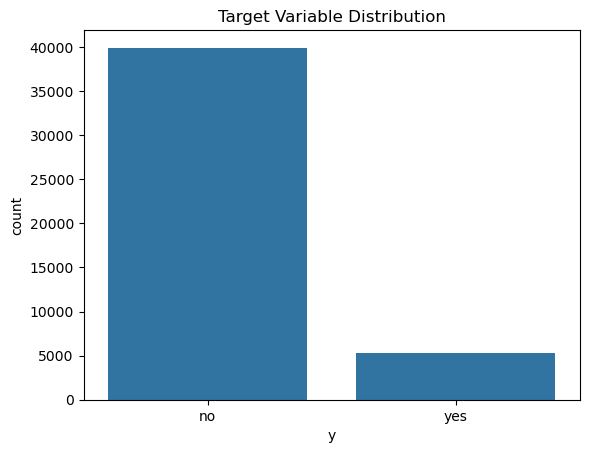

In [112]:
sns.countplot(x = 'y', data = df)
plt.title('Target Variable Distribution')
plt.show()

###### Observation 
Dataset is imbalanced   

"No" class is much largeer than "Yes"

#### Age Distribution 

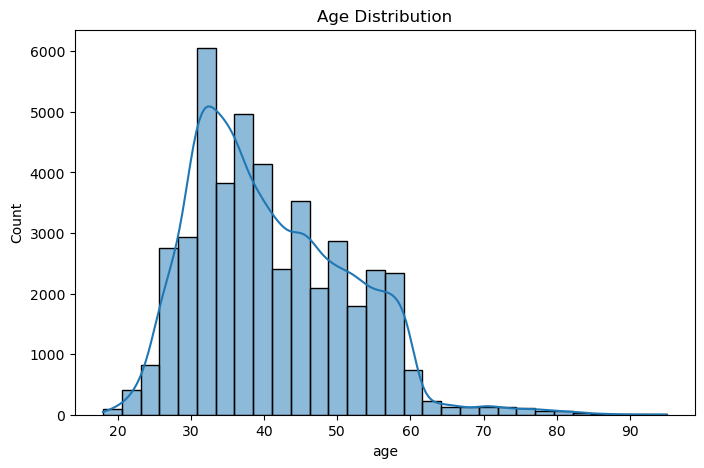

In [113]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

#### Job Distribution 

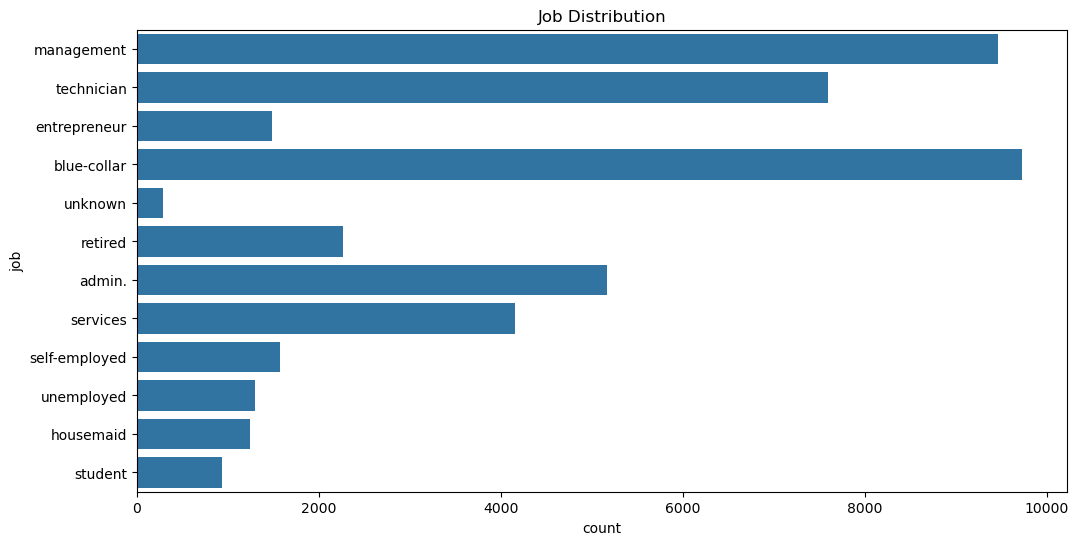

In [116]:
plt.figure(figsize = (12,6))
sns.countplot(y='job', data=df)
plt.title('Job Distribution')
plt.show()

#### Correlation Heatmap

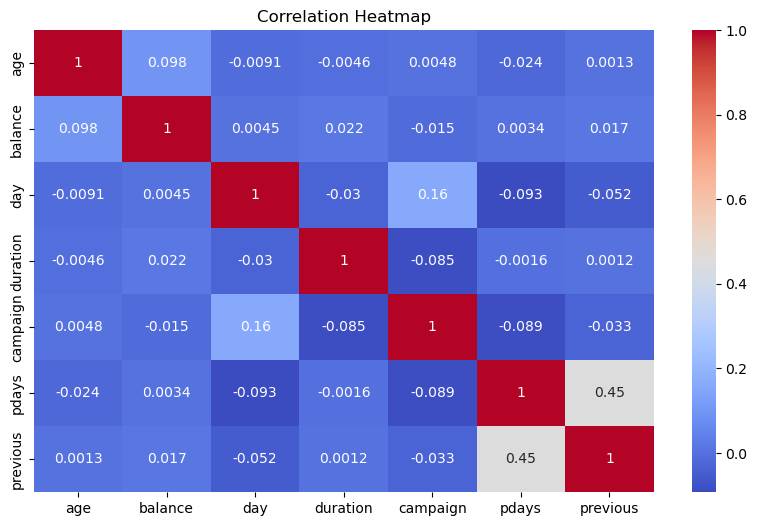

In [117]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Feature Selection

#### Separate Features and Target

In [122]:
X = df.drop('y', axis = 1)
y = df['y']

#### Remove Leakage Column 

In [123]:
X = X.drop('duration', axis = 1)

The above column duration causes target leakage. 
It contains call duration information that become strongly related to 
Whether the customer subscribed. Keeping it can create unrealistically high accuracy

## Train/Test Split
Always split BEFORE encoding and scalling.

In [124]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## One-Hot Encoding
Convert categorical columns into numerical format.

In [125]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

## Align Train and Test Columns
Dummy encoding may create mismatched columns.

This step ensures:

same columns
same order

In [126]:
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

## Feature Scaling
Scaling is important for:

Logistic Regression
Distance-based algorithms

Not very important for:

Decision Trees
Random Forest

#### Identify Numeric Columns

In [127]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

#### Apply StandardScaler

In [128]:
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

## Logistic Regression Model

In [129]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

#### Predictions

In [130]:
lr_pred = lr_model.predict(X_test)

#### Evaluation

In [131]:
print('Accuracy:', accuracy_score(y_test, lr_pred))

Accuracy: 0.8932876257879022


#### Confusion Matrix

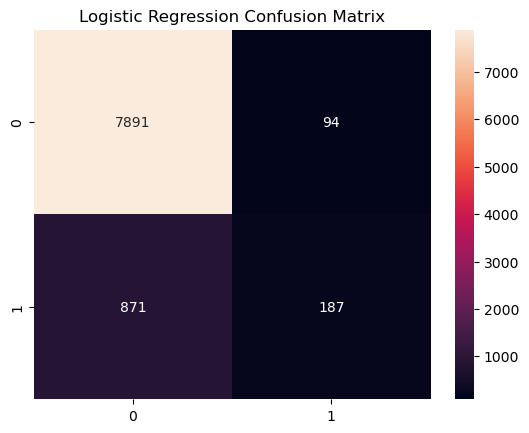

In [132]:
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

#### Classification Report
Focus especially on:

Precision, 
Recall, 
F1-Score

In [133]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

          no       0.90      0.99      0.94      7985
         yes       0.67      0.18      0.28      1058

    accuracy                           0.89      9043
   macro avg       0.78      0.58      0.61      9043
weighted avg       0.87      0.89      0.86      9043



## Decision Tree Model
Decision Trees can easily overfit.

So we control the depth

In [135]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

#### Predictions

In [136]:
dt_pred = dt_model.predict(X_test)

#### Evaluation

In [137]:
print('Decision Tree Accuracy:', accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.8928452947030853


#### Classification Report

In [138]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

          no       0.90      0.99      0.94      7985
         yes       0.69      0.15      0.25      1058

    accuracy                           0.89      9043
   macro avg       0.79      0.57      0.60      9043
weighted avg       0.87      0.89      0.86      9043



## Random Forest Model
Random Forest usually performs best on this dataset.

In [139]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_split=10, n_estimators=200,
                       random_state=42)

#### Predictions

In [140]:
rf_pred = rf_model.predict(X_test)

#### Evaluation

In [141]:
print('Random Forest Accuracy:', accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8951675328983745


#### Classification Report

In [142]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

          no       0.90      0.99      0.94      7985
         yes       0.72      0.17      0.27      1058

    accuracy                           0.90      9043
   macro avg       0.81      0.58      0.61      9043
weighted avg       0.88      0.90      0.87      9043



## ROC-AUC Score
ROC-AUC is better than accuracy for imbalanced datasets.

### Logistic Regression ROC-AUC

In [143]:
lr_probs = lr_model.predict_proba(X_test)[:,1]

print('Logistic Regression ROC-AUC:',
      roc_auc_score(y_test.map({'no':0,'yes':1}), lr_probs))

Logistic Regression ROC-AUC: 0.7716923153407915


### Random Forest ROC-AUC

In [144]:
rf_probs = rf_model.predict_proba(X_test)[:,1]

print('Random Forest ROC-AUC:',
      roc_auc_score(y_test.map({'no':0,'yes':1}), rf_probs))

Random Forest ROC-AUC: 0.7934227456253633


## Feature Importance

Feature importance helps identify the most influential variables.

### Random Forest Feature Importance

In [145]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

### Sort Features

In [146]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

### Top 10 Features

In [147]:
print(feature_importance.head(10))

             Feature  Importance
39  poutcome_success    0.257907
0                age    0.092942
4              pdays    0.088590
23       housing_yes    0.053656
1            balance    0.050599
2                day    0.049088
26   contact_unknown    0.043170
33         month_mar    0.041910
5           previous    0.037480
36         month_oct    0.033494


### Visualize Feature Importance

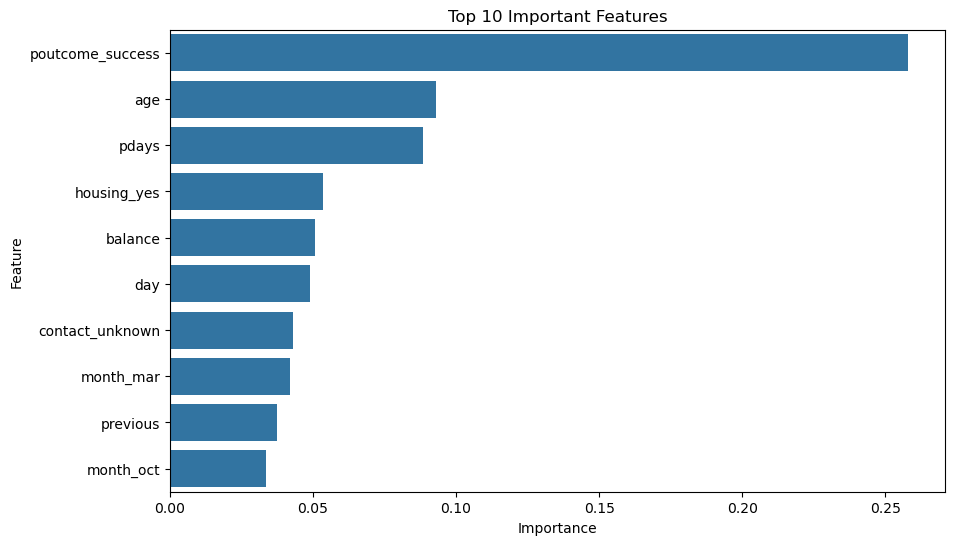

In [148]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title('Top 10 Important Features')
plt.show()

## Cross Validation

Cross Validation gives more reliable performance.

In [149]:
from sklearn.model_selection import cross_val_score

### Logistic Regression CV

In [150]:
cv_scores = cross_val_score(
    lr_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

### Average Accuracy

In [151]:
print('Average CV Accuracy:', cv_scores.mean())

Average CV Accuracy: 0.8926399335274106


# Final Model Comparison

In [152]:
models = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

# Display Results

In [153]:
print(models)

                 Model  Accuracy
0  Logistic Regression  0.893288
1        Decision Tree  0.892845
2        Random Forest  0.895168


## Expected Realistic Results
Model	Expected Accuracy

Logistic Regression = 	 88% – 91%

Decision Tree       =  84% – 89%

Random Forest       = 89% – 93%

## Final Interpretation 
### Logistic Regression

Strengths:
1. Simple
2. Interpretable
3. Fast
4. Good baseline model

Weakness:

Cannot capture complex nonlinear patterns

### Decision Tree

Strengths:
1. Easy to understand
2. Good visualization
3. Captures nonlinear relationships

Weakness:

Overfits easily

### Random Forest

Strengths:

1. Usually highest accuracy
2. Handles nonlinear patterns
3. More robust
4. Reduces overfitting

Weakness:

Less interpretable

## Best Model Recommendation
For this Bank Marketing dataset:
## Recommended Final Model
RandomForestClassifier

because it usually gives:
1. best balance
2. strong generalization
3. high predictive performance